In [1]:
import os
import sys
from pathlib import Path
import matplotlib.pyplot as plt
import torch
project_root = os.path.abspath(os.path.join(os.getcwd(), '..'))
sys.path.append(project_root)

In [2]:
import pandas as pd
import numpy as np
import src.features.seismic_features as sf

In [3]:
def process_cn_catalog(dat_file):
    column_names = ['Year', 'Month', 'Day', 'Hour', 'Minute', 'Second', 'Latitude', 'Longitude', 'Depth', 'Magnitude']
    df = pd.read_csv(dat_file, header=None, names=column_names, sep='\s+')
    print(df)
    data_input = df.to_numpy()
    year = data_input[:, 0].astype(int)
    month = data_input[:, 1].astype(int)
    day = data_input[:, 2].astype(int)
    hour = data_input[:, 3].astype(int)
    minute = data_input[:, 4].astype(int)
    second = data_input[:, 5]
    
    data = np.column_stack((year, month, day, hour, minute, second))
    jd0 = sf.cal2jd([1970, 1, 1, 0, 0, 0])
    jd = np.array([sf.cal2jd(d) - jd0 for d in data])

    df.loc[:, 't'] = jd
    df['dt'] = df['t'].diff().fillna(0)
    df['ts'] = pd.to_datetime(
        df[['Year', 'Month', 'Day', 'Hour', 'Minute']].assign(Second=df['Second']),
        errors='coerce'  
    )
    df = df[['t', 'Magnitude', 'Latitude', 'Longitude', 'Depth', 'dt','ts']]
    csv_file = os.path.splitext(dat_file)[0] + '.csv'
    df.to_csv(csv_file, index=False)
    return df


<>:3: SyntaxWarning: invalid escape sequence '\s'
<>:3: SyntaxWarning: invalid escape sequence '\s'
/root/autodl-tmp/tmp/ipykernel_7228/1379735965.py:3: SyntaxWarning: invalid escape sequence '\s'
  df = pd.read_csv(dat_file, header=None, names=column_names, sep='\s+')


In [4]:
base_dir = os.path.join(project_root,'data', 'ChinaArray')
dat_files = [f for f in os.listdir(os.path.join(base_dir, 'raw')) if f.endswith('.dat')]
print(dat_files)
df1 = process_cn_catalog(os.path.join(base_dir, 'raw', dat_files[0]))

['ChinaArray.dat', 'ChinaArrary.dat']
         Year  Month  Day  Hour  Minute  Second  Latitude  Longitude  Depth  \
0        1970      1    1    12      55   16.00    26.050    100.980      0   
1        1970      1    2     6      14   14.60    38.100    119.470     26   
2        1970      1    2    10      56    0.00    37.200    114.830     17   
3        1970      1    2    13      45    5.00    40.300     77.000      0   
4        1970      1    2    18      56    0.00    35.700    122.500      0   
...       ...    ...  ...   ...     ...     ...       ...        ...    ...   
1495637  2023      8   13    23      17   37.45    37.922    115.216     12   
1495638  2023      8   13    23      27   38.85    37.916    115.246     26   
1495639  2023      8   13    23      29   35.34    24.327    101.880     15   
1495640  2023      8   13    23      29   59.71    23.850    114.501      9   
1495641  2023      8   13    23      49   13.80    29.726    106.016     13   

         Magn

/root/autodl-tmp/tmp/ipykernel_7228/1379735965.py:3: SyntaxWarning: invalid escape sequence '\s'
  df = pd.read_csv(dat_file, header=None, names=column_names, sep='\s+')


KeyboardInterrupt: 

In [ ]:
df1['ts']

0         1970-01-01 12:55:16.000
1         1970-01-02 06:14:14.600
2         1970-01-02 10:56:00.000
3         1970-01-02 13:45:05.000
4         1970-01-02 18:56:00.000
                    ...          
1495637   2023-08-13 23:17:37.450
1495638   2023-08-13 23:27:38.850
1495639   2023-08-13 23:29:35.340
1495640   2023-08-13 23:29:59.710
1495641   2023-08-13 23:49:13.800
Name: ts, Length: 1495642, dtype: datetime64[ns]

In [ ]:
base_dir = os.path.join(project_root,'data', 'ChuanDian')
dat_files = [f for f in os.listdir(os.path.join(base_dir, 'raw')) if f.endswith('.dat')]
print(dat_files)
df4 = process_cn_catalog(os.path.join(base_dir, 'raw', dat_files[0]))

['Chuandian2021.dat']
        Year  Month  Day  Hour  Minute  Second  Latitude  Longitude  Depth  \
0       1970      1    1    12      55   16.00    26.050    100.980      0   
1       1970      1    5     1       0   34.00    24.100    102.600     13   
2       1970      1    5     1      32   40.00    24.200    102.450      0   
3       1970      1    5     1      46    0.00    24.200    102.450      0   
4       1970      1    5     1      57    0.00    24.200    102.450      0   
...      ...    ...  ...   ...     ...     ...       ...        ...    ...   
571126  2021      5   23    23      55   24.85    25.671     99.907      8   
571127  2021      5   23    23      55   43.49    25.690     99.900      8   
571128  2021      5   23    23      56   26.67    25.647     99.890      8   
571129  2021      5   23    23      57   12.92    25.687     99.905      8   
571130  2021      5   23    23      58   21.72    25.591    100.000      8   

        Magnitude  
0             2.7  
1

In [ ]:
df4['ts']

0        1970-01-01 12:55:16.000
1        1970-01-05 01:00:34.000
2        1970-01-05 01:32:40.000
3        1970-01-05 01:46:00.000
4        1970-01-05 01:57:00.000
                   ...          
571126   2021-05-23 23:55:24.850
571127   2021-05-23 23:55:43.490
571128   2021-05-23 23:56:26.670
571129   2021-05-23 23:57:12.920
571130   2021-05-23 23:58:21.720
Name: ts, Length: 571131, dtype: datetime64[ns]

In [ ]:
def process_synthetic_catlog(dat_file):
    column_names =["ID1", "ID2", "t", "Magnitude", "Depth", "Longitude", "Latitude"]
    df = pd.read_csv(dat_file, header=None, names=column_names, sep='\s+')
    df['dt'] = df['t'].diff().fillna(0)
    df = df[['t', 'Magnitude', 'Latitude', 'Longitude', 'Depth', 'dt']]
    # 保存为同名csv文件
    csv_file = os.path.splitext(dat_file)[0] + '.csv'
    df.to_csv(csv_file, index=False)
    
    return df

<>:3: SyntaxWarning: invalid escape sequence '\s'
<>:3: SyntaxWarning: invalid escape sequence '\s'
/root/autodl-tmp/tmp/ipykernel_22570/2041208704.py:3: SyntaxWarning: invalid escape sequence '\s'
  df = pd.read_csv(dat_file, header=None, names=column_names, sep='\s+')


In [ ]:
base_dir = os.path.join(project_root,'data', 'AZDX-taper')
dat_files = [f for f in os.listdir(os.path.join(base_dir, 'raw')) if f.endswith('.dat')]
df2 = process_synthetic_catlog(os.path.join(base_dir, 'raw', dat_files[0]))

In [ ]:
print(df2)

               t  Magnitude  Latitude  Longitude   Depth      dt
0        708.562      4.753    29.196    102.273     0.0   0.000
1        719.140      4.754    29.277    102.278     0.0  10.578
2        746.241      5.012    29.169    102.272     0.0  27.101
3        757.513      4.754    29.277    102.278     0.0  11.272
4        770.426      4.754    29.169    102.272     0.0  12.913
...          ...        ...       ...        ...     ...     ...
48801  19999.500      4.717    26.579    103.007 -3000.0   0.000
48802  19999.700      4.742    26.500    103.030     0.0   0.200
48803  19999.800      4.750    25.590    103.248     0.0   0.100
48804  19999.900      4.716    27.686    102.892 -3000.0   0.100
48805  20000.400      4.747    27.232    102.616     0.0   0.500

[48806 rows x 6 columns]


In [ ]:
base_dir = os.path.join(project_root,'data', 'AZDX')
dat_files = [f for f in os.listdir(os.path.join(base_dir, 'raw')) if f.endswith('.dat')]
df3 = process_synthetic_catlog(os.path.join(base_dir, 'raw', dat_files[0]))

In [ ]:
print(df3)

                t  Magnitude  Latitude  Longitude    Depth     dt
0         115.046      4.720    29.277    102.278 -18000.0  0.000
1         121.259      4.720    29.277    102.278 -18000.0  6.213
2         127.471      4.720    29.277    102.278 -18000.0  6.212
3         133.684      4.720    29.277    102.278 -18000.0  6.213
4         137.617      4.720    29.277    102.278 -15000.0  3.933
...           ...        ...       ...        ...      ...    ...
172841  19999.700      4.969    27.938    102.232  -6000.0  0.000
172842  19999.900      4.712    23.637    102.966 -18000.0  0.200
172843  19999.900      4.704    27.140    102.680 -18000.0  0.000
172844  20000.000      4.699    24.323    103.117 -18000.0  0.100
172845  20000.300      5.228    26.920    102.832 -18000.0  0.300

[172846 rows x 6 columns]


In [ ]:
def process_recast_catalog(csv_file, metadata_file):
    df = pd.read_csv(csv_file)
    meta_data = torch.load(metadata_file, weights_only=False)
    start_ts = pd.to_datetime(meta_data['start_ts'])
    df['ts'] = pd.to_datetime(df['time'])
    jd0 = sf.cal2jd(start_ts)
    jd = np.array([sf.cal2jd(d) - jd0 for d in df['ts']])
    df['t'] = jd
    df['dt'] = df['t'].diff().fillna(0)
    df = df[['t', 'magnitude', 'latitude', 'longitude', 'depth', 'dt', 'ts']]
    csv_file = Path(csv_file)
    save_file = csv_file.parent / f'processed_{csv_file.stem}.csv'
    df.rename(columns={'magnitude': 'Magnitude', 'latitude': 'Latitude', 'longitude': 'Longitude', 'depth': 'Depth'}, inplace=True)
    df.to_csv(save_file, index=False)
    return df

In [ ]:
df_scedc = process_recast_catalog(
    '../data/SCEDC/raw/SCEDC.csv',
    '../data/SCEDC/raw/metadata.pt'
)

df_white = process_recast_catalog(
    '../data/White/raw/White.csv',
    '../data/White/raw/metadata.pt'
)

df_SaltonSea = process_recast_catalog(
    '../data/QTMSaltonSea/raw/SaltonSea.csv',
    '../data/QTMSaltonSea/raw/metadata.pt'
)

df_SanJacinto = process_recast_catalog(
    '../data/QTMSanJacinto/raw/SanJacinto.csv',
    '../data/QTMSanJacinto/raw/metadata.pt'
)


In [ ]:
def plot_dt_distributions(dfs, names=None, bins=100, figsize=(20, 4)):
    if names is None:
        names = [f'df{i+1}' for i in range(len(dfs))]

    plt.figure(figsize=figsize)
    
    for i, (df, name) in enumerate(zip(dfs, names)):
        plt.subplot(1, len(dfs), i + 1)
        dt = df['dt'].dropna()
        plt.hist(dt, bins=bins, alpha=0.7, color=f'C{i}')
        mean = dt.mean()
        std = dt.std()

        plt.axvline(mean, color='red', linestyle='dashed', linewidth=1, label=f'Mean: {mean:.2f}')
        plt.axvline(mean + std, color='green', linestyle='dotted', linewidth=1, label=f'Std: {std:.2f}')
        plt.axvline(mean - std, color='green', linestyle='dotted', linewidth=1)
        plt.title(f'{name} dt distribution')
        plt.xlabel('dt')
        plt.ylabel('Count')
        plt.legend()

    plt.tight_layout()
    plt.show()


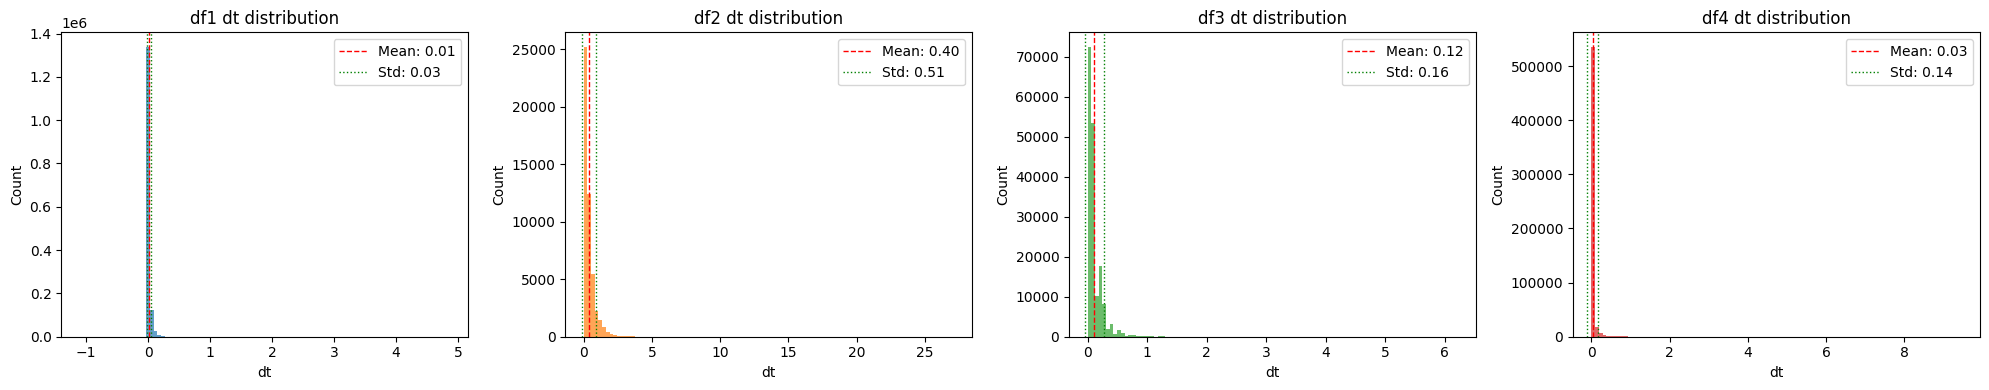

In [ ]:
plot_dt_distributions(
    [df1, df2, df3, df4],
    names=['df1', 'df2', 'df3', 'df4'],
    bins=100
)


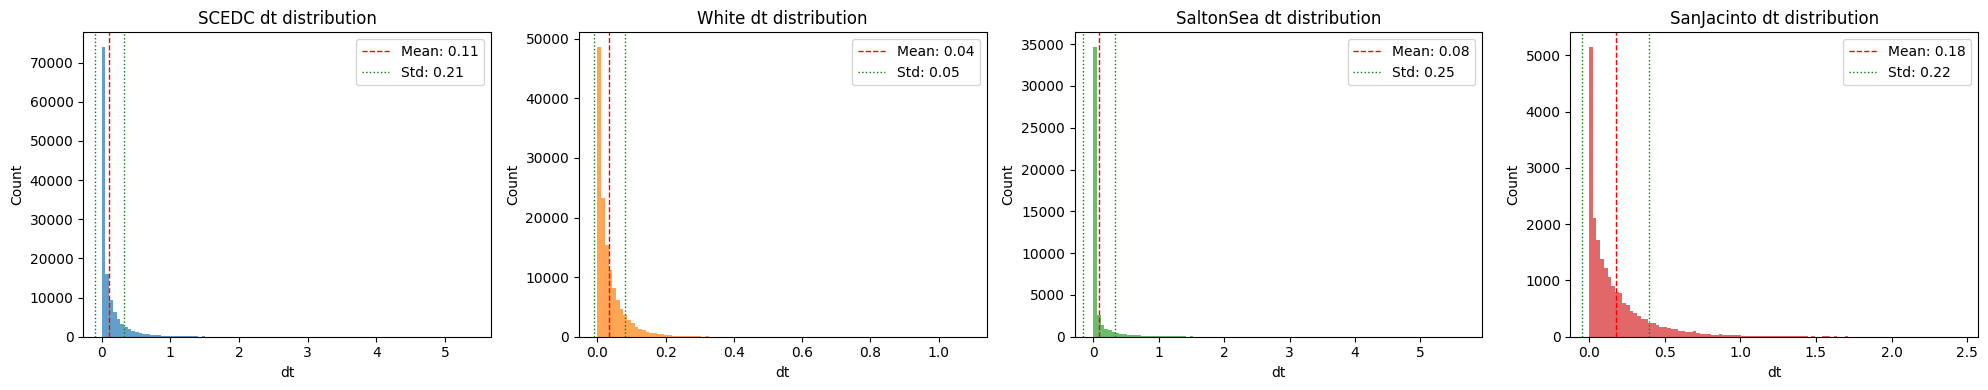

In [ ]:
plot_dt_distributions(
    [df_scedc, df_white, df_SaltonSea, df_SanJacinto],
    names=['SCEDC', 'White', 'SaltonSea', 'SanJacinto'],
    bins=100,
    figsize=(20, 4)
)


In [ ]:
print(df_scedc['ts'])

0        1981-01-01 04:13:55.640
1        1981-01-01 05:20:14.670
2        1981-01-01 15:05:24.760
3        1981-01-02 15:03:09.420
4        1981-01-02 16:45:32.810
                   ...          
125663   2019-12-31 00:57:25.880
125664   2019-12-31 08:04:45.970
125665   2019-12-31 14:58:57.420
125666   2019-12-31 15:17:20.590
125667   2019-12-31 17:06:30.580
Name: ts, Length: 125668, dtype: datetime64[ns]


In [ ]:
df4['dt'].max

<bound method Series.max of 0         0.000000
1         3.503681
2         0.022292
3         0.009259
4         0.007639
            ...   
571126    0.000481
571127    0.000216
571128    0.000500
571129    0.000535
571130    0.000796
Name: dt, Length: 571131, dtype: float64>

In [ ]:
def load_and_filter_catalog(base_dir, Mc):
    raw_dir = os.path.join(base_dir, 'raw')
    csv_files = [f for f in os.listdir(raw_dir) if f.endswith('.csv')]
    print("CSV files found:", csv_files)

    if len(csv_files) == 1:
        chosen_file = csv_files[0]
    elif len(csv_files) > 1:
        processed_files = [f for f in csv_files if f.startswith('processed_')]
        if len(processed_files) != 1:
            raise ValueError(f"Expected exactly one 'processed_' CSV file among multiple files, found {len(processed_files)}: {processed_files}")
        chosen_file = processed_files[0]
    else:
        raise ValueError("No CSV files found in the 'raw' directory.")

    df = pd.read_csv(os.path.join(raw_dir, chosen_file))
    df = df[df['Magnitude'] >= Mc].reset_index(drop=True)
    return df


In [ ]:
base_dir = "../data/White"

In [ ]:
df = load_and_filter_catalog(base_dir, Mc=5.0)
print(df)

CSV files found: ['catalog.csv', 'White.csv', 'processed_White.csv']
             t  Magnitude   Latitude   Longitude   Depth        dt  \
0   210.779492       5.35  33.589203 -116.993057   8.853  0.071254   
1  1896.705617       5.13  33.500340 -116.440580  13.887  0.002664   
2  3083.336551       5.54  33.446884 -116.429810  16.511  0.001771   
3  4477.078682       5.15  33.497158 -116.484131  16.029  0.000741   

                        ts  
0  2008-07-29 18:42:28.102  
1  2013-03-11 16:56:05.312  
2  2016-06-10 08:04:37.994  
3  2020-04-04 01:53:18.131  


In [ ]:
import geopandas as gpd
import geodatasets
import matplotlib.pyplot as plt
def plot_epicenters(df, title="Earthquake Epicenter Distribution (ChinaArray)"):
    gdf = gpd.GeoDataFrame(
        df,
        geometry=gpd.points_from_xy(df['Longitude'], df['Latitude']),
        crs="EPSG:4326"
    )

    world = gpd.read_file(geodatasets.get_path("naturalearth.land"))

 
    fig, ax = plt.subplots(figsize=(10, 8))
    world.boundary.plot(ax=ax, linewidth=0.5, edgecolor='gray')  
    gdf.plot(ax=ax, color='red', markersize=5, label='ChinaArray') 

    ax.set_title(title, fontsize=14)
    ax.legend()
    ax.set_axis_off()  # 去掉坐标轴更美观也更快
    
    plt.tight_layout()
    plt.show()

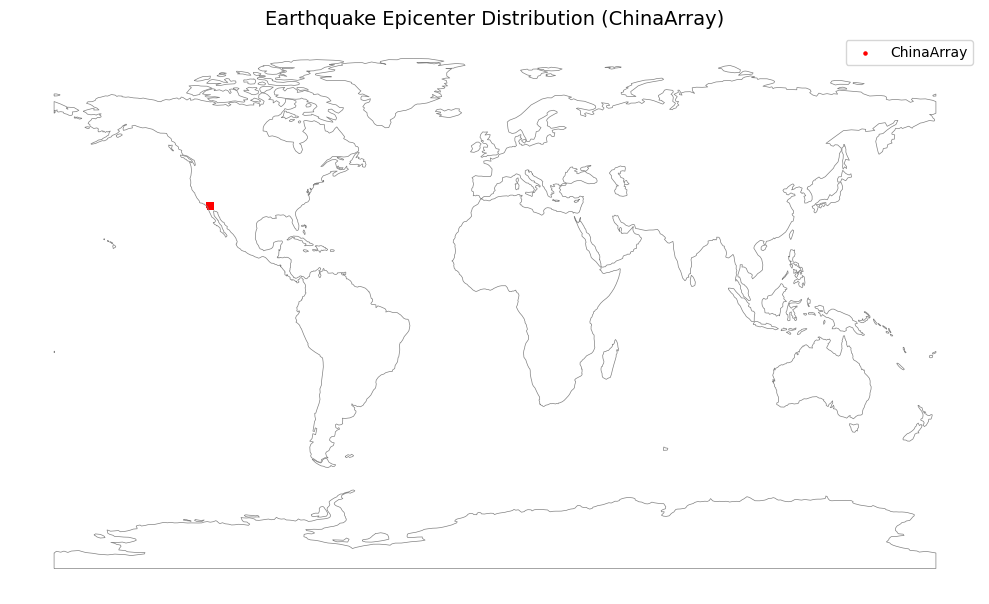

In [ ]:
plot_epicenters(df_SanJacinto)

In [ ]:
def get_time_range_from_df(df):
    """
    Extracts the timestamp from a DataFrame with separate time columns
    and returns the minimum and maximum datetime values.

    Parameters:
        df (pd.DataFrame): DataFrame with columns: 
            'Year', 'Month', 'Day', 'Hour', 'Minute', 'Second'

    Returns:
        tuple: (start_time, end_time) as pd.Timestamp objects
    """
    # Combine separate time columns into a single datetime column
    df['time'] = pd.to_datetime(
        df[['Year', 'Month', 'Day', 'Hour', 'Minute']].assign(Second=df['Second']),
        errors='coerce'  # Invalid combinations become NaT
    )

    valid_times = df['time'].dropna()

    start_time = valid_times.min()
    end_time = valid_times.max()
    return start_time, end_time

In [ ]:
from  src.data.preprocessing import load_and_filter_catalog
df = load_and_filter_catalog('/home/yzzhang/pjt/chuandian_eq/data/White', Mc=1.0)

CSV files found: ['catalog.csv', 'White.csv', 'processed_White.csv']


<Axes: >

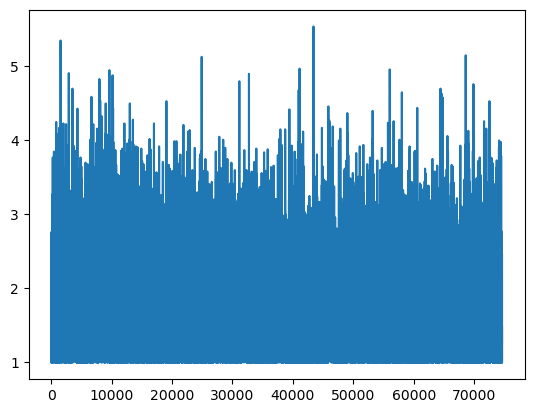

In [ ]:
df['Magnitude'].plot()

In [ ]:
from src.features.seismic_features import  calculate_magnitudes_and_features
b_lsq, a_lsq, std_gr_lsq, b_mlk, a_mlk, std_gr_mlk, dM_lsq, dM_mlk, b_std_lsq, b_std_mlk, num_Mag_int = calculate_magnitudes_and_features(df['Magnitude'], Mc=3.0,dMag=0.1)

In [ ]:
print(b_lsq,b_mlk)

0.8195596926435272 0.9504908498211828
